# Notebook 05 — Layer 3: TTS-Vergleich

**Ziel:** Die drei TTS-Provider (Deepgram, OpenAI, Azure) systematisch vergleichen.

**Eingabe:** `data/processed/layer3_tts.parquet` — 16.796 erfolgreiche Messungen.

**Metriken:**
- `connect_ms` — TCP+TLS-Verbindungsaufbau
- `ttfa_ms` — Time to First Audio (User-facing: wann kommt das erste Audio-Byte?)
- `total_ms` — Gesamtdauer bis Audio vollständig übertragen
- `proc_ms` (berechnet) — Server-Verarbeitungszeit = `ttfa_ms - connect_ms`

**Infrastruktur-Kontext (aus NB 01/02):**
- **Deepgram TTS:** US-gehostet (Anycast, AS Cogent-174/Zayo-6461), ICMP-RTT ~138 ms
- **Azure TTS:** EU Italy North (AS 8075 / Microsoft), RTT ~11-16 ms
- **OpenAI TTS:** Cloudflare-fronted Frankfurt (AS 13335), RTT ~1-2 ms

**Erwartung aus Infrastruktur:** Azure (EU, niedriger RTT) sollte schnellstes `ttfa_ms` haben.
OpenAI (Cloudflare-Edge, ~0 ms connect) könnte bei Verarbeitung überraschen.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from _helpers import load_layer3, save_figure, save_table, PROVIDER_COLORS

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

tts = load_layer3('tts')
tts['proc_ms'] = tts['ttfa_ms'] - tts['connect_ms']

TTS_ORDER = ['azure', 'deepgram', 'openai']
COLORS = {api: PROVIDER_COLORS[api] for api in TTS_ORDER}

print(f'Zeilen gesamt: {len(tts):,}')
print(tts['api'].value_counts())
print()
print('Datum-Bereich:', tts['ts'].min().date(), 'bis', tts['ts'].max().date())

Zeilen gesamt: 16,796
api
deepgram    5599
openai      5599
azure       5598
Name: count, dtype: int64

Datum-Bereich: 2026-06-01 bis 2026-06-07


## 1. Deskriptive Statistik

Sortierung nach erwartetem ttfa_ms-Ranking (azure → deepgram → openai).

`proc_ms` trennt den Netzwerk-Anteil (connect_ms) vom reinen Engine-Anteil.
Dadurch lässt sich unterscheiden: Ist ein Provider schnell, weil er nah ist
(niedriges connect_ms), oder weil seine TTS-Engine schnell ist (niedriges proc_ms)?

In [2]:
METRICS = ['connect_ms', 'proc_ms', 'ttfa_ms', 'total_ms']

rows = []
for api in TTS_ORDER:
    sub = tts[tts['api'] == api]
    for m in METRICS:
        s = sub[m].dropna()
        rows.append({
            'provider': api, 'metric': m, 'n': len(s),
            'p50':  round(s.quantile(.50), 1),
            'p90':  round(s.quantile(.90), 1),
            'p95':  round(s.quantile(.95), 1),
            'p99':  round(s.quantile(.99), 1),
            'mean': round(s.mean(), 1),
            'std':  round(s.std(), 1),
        })

stats_df = pd.DataFrame(rows)
save_table(stats_df, '05_tts_statistics', index=False)
stats_df

  saved tables/05_tts_statistics.csv


,provider,metric,n,p50,p90,p95,p99,mean,std
0,azure,connect_ms,5598,33.3,39.7,43.4,57.0,34.8,13.9
1,azure,proc_ms,5598,33.2,49.3,76.1,442.8,47.9,106.7
2,azure,ttfa_ms,5598,66.6,86.9,113.2,475.6,82.7,108.0
3,azure,total_ms,5598,183.8,230.0,296.1,611.3,207.2,155.0
4,deepgram,connect_ms,5599,290.8,312.8,319.2,339.3,276.0,50.0
5,deepgram,proc_ms,5599,262.3,292.7,314.8,373.3,256.1,52.9
6,deepgram,ttfa_ms,5599,556.5,592.7,603.6,630.8,532.0,76.3
7,deepgram,total_ms,5599,1935.6,2078.4,2150.3,2299.9,1923.8,173.4
8,openai,connect_ms,5599,9.2,13.5,16.6,28.5,10.6,18.3
9,openai,proc_ms,5599,943.6,1625.1,1822.9,2734.0,1060.2,789.0


## 2. Verteilungs-Visualisierung — CDF ttfa_ms

Zeigt direkt: Bei welchem ms-Wert erreicht jeder Provider 50%/90%/95% seiner Calls.
Die 500-ms-Linie markiert ein anspruchsvolles Voice-UI-Budget für TTS.

  saved figures/05_tts/{png,pdf}/05_tts_ttfa_cdf


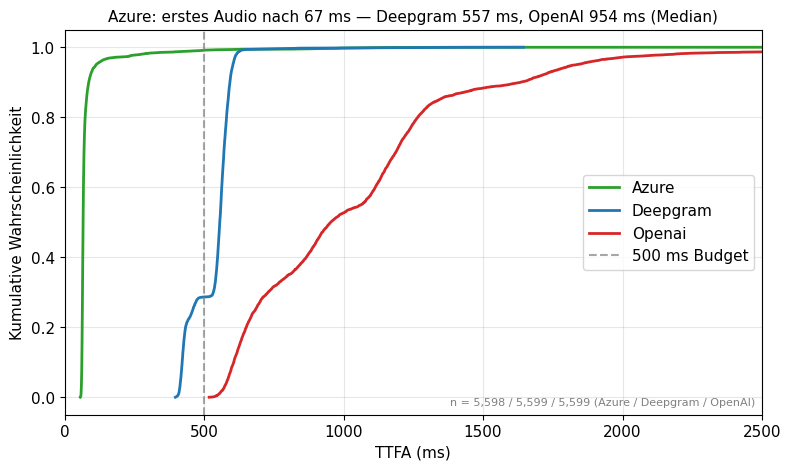

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
n_per = {}
for api in TTS_ORDER:
    sub = tts[tts['api'] == api]['ttfa_ms'].sort_values()
    n_per[api] = len(sub)
    cdf = np.arange(1, len(sub) + 1) / len(sub)
    ax.plot(sub, cdf, color=COLORS[api], linewidth=2, label=api.capitalize())

ax.axvline(500, color='gray', linestyle='--', alpha=0.7, label='500 ms Budget')
ax.set_xlabel('TTFA (ms)')
ax.set_ylabel('Kumulative Wahrscheinlichkeit')
ax.set_title('Azure: erstes Audio nach 67 ms — Deepgram 557 ms, OpenAI 954 ms (Median)', fontsize=11)
ax.set_xlim(0, 2500)
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.99, 0.02, f'n = {n_per["azure"]:,} / {n_per["deepgram"]:,} / {n_per["openai"]:,} (Azure / Deepgram / OpenAI)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')
save_figure(fig, '05_tts_ttfa_cdf')
plt.show()

## 3. Azure-Phänomen: Netzwerk oder Engine?

Azure TTS hat das schnellste `ttfa_ms`. Die zentrale Frage:
Kommt das vom niedrigen RTT (EU Italy North, ~11-16 ms) oder von einer
schnellen TTS-Engine (niedriges `proc_ms`)?

**Methodik:** `proc_ms = ttfa_ms - connect_ms` isoliert die Server-Verarbeitungszeit.
Wenn `proc_ms` bei Azure auch am niedrigsten ist → Engine-Effekt dominiert.
Wenn `proc_ms` ähnlich wie andere Provider → reiner Netzwerk-Effekt.

Stacked-Bar zeigt die Zusammensetzung von `ttfa_ms` pro Provider.

Zerlegung TTFA in connect_ms + proc_ms:
provider  connect_p50  proc_p50  ttfa_p50  connect_share
   azure         33.3      33.2      66.6           50.0
deepgram        290.8     262.3     556.5           52.3
  openai          9.2     943.6     954.2            1.0


  saved figures/05_tts/{png,pdf}/05_tts_connect_anteil


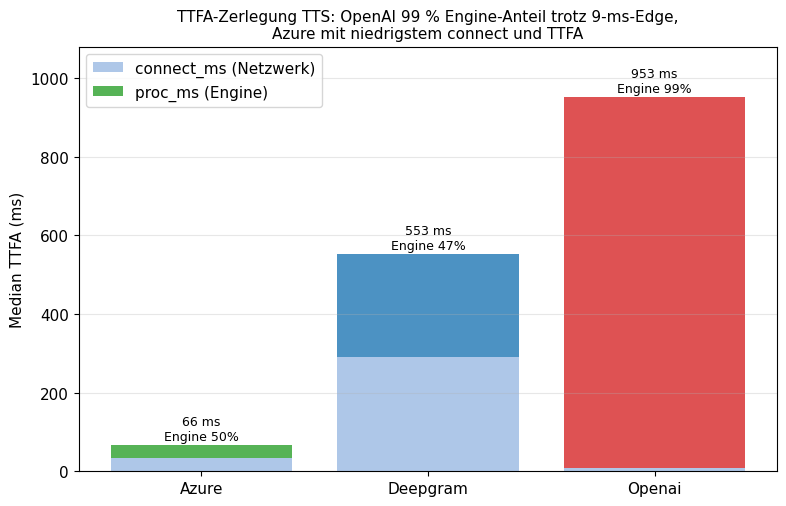

In [4]:
# Tabelle: connect vs proc Aufschlüsselung
decomp = pd.DataFrame([{
    'provider':      api,
    'connect_p50':   round(tts[tts['api'] == api]['connect_ms'].median(), 1),
    'proc_p50':      round(tts[tts['api'] == api]['proc_ms'].median(), 1),
    'ttfa_p50':      round(tts[tts['api'] == api]['ttfa_ms'].median(), 1),
    'connect_share': round(tts[tts['api'] == api]['connect_ms'].median() /
                           tts[tts['api'] == api]['ttfa_ms'].median() * 100, 1),
} for api in TTS_ORDER])
print('Zerlegung TTFA in connect_ms + proc_ms:')
print(decomp.to_string(index=False))

# Stacked Bar
fig, ax = plt.subplots(figsize=(8, 5.2))
for i, api in enumerate(TTS_ORDER):
    conn = tts[tts['api'] == api]['connect_ms'].median()
    proc = tts[tts['api'] == api]['proc_ms'].median()
    ax.bar(api.capitalize(), conn, color='#aec7e8',
           label='connect_ms (Netzwerk)' if i == 0 else '')
    ax.bar(api.capitalize(), proc, bottom=conn, color=COLORS[api], alpha=0.8,
           label='proc_ms (Engine)' if i == 0 else '')
    total = conn + proc
    share = proc / total * 100
    ax.text(i, total + 5, f'{total:.0f} ms\nEngine {share:.0f}%',
            ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Median TTFA (ms)')
ax.set_title('TTFA-Zerlegung TTS: OpenAI 99 % Engine-Anteil trotz 9-ms-Edge,\nAzure mit niedrigstem connect und TTFA', fontsize=11)
ax.set_ylim(0, 1080)
ax.legend(loc='upper left')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
save_figure(fig, '05_tts_connect_anteil')
plt.show()

## 6. total_ms: Gesamtübertragungsdauer

`ttfa_ms` misst wann das erste Audio-Byte ankommt — für Voice-UI die wichtigste Metrik.
`total_ms` misst wie lange das Streaming der gesamten Antwort dauert.

Bei kurzen TTS-Texten ("Good morning! How can I assist you today?", ~5-6 Wörter)
sollte `total_ms` nicht weit über `ttfa_ms` liegen. Ein großer Abstand deutet auf
langsame Übertragungsrate oder Audio-Chunking hin.

Deepgram hat laut Statistik ein besonders hohes `total_ms` (p50=1936 ms) trotz
moderatem `ttfa_ms` (p50=557 ms) — zu prüfen ob das an Chunk-Größe oder
Audio-Format liegt.

  saved figures/05_tts/{png,pdf}/05_tts_total_ms


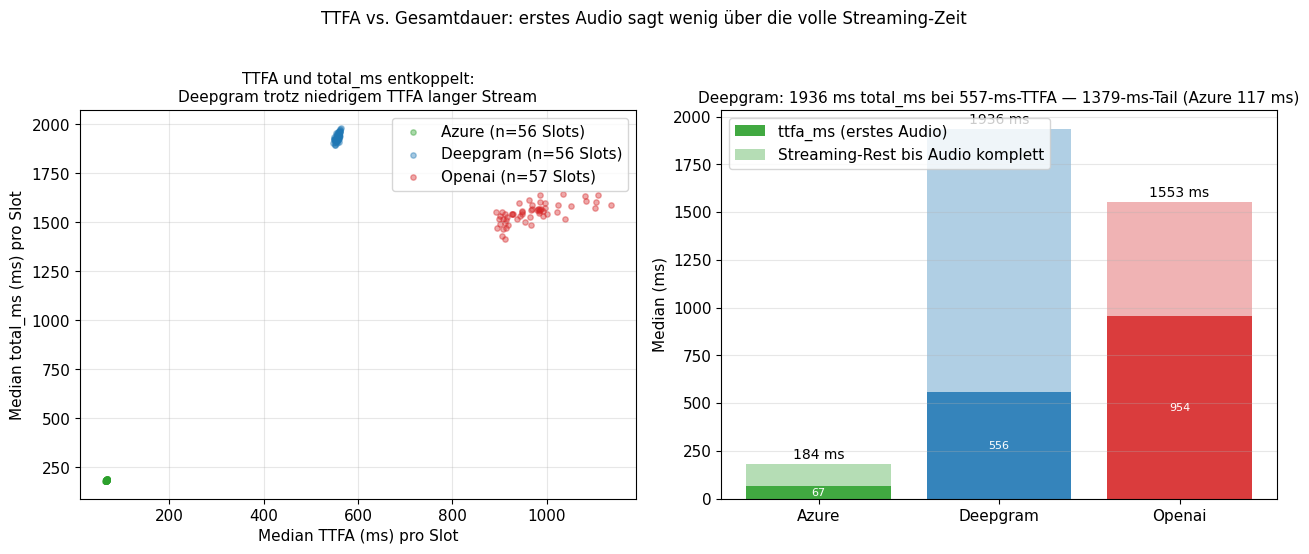

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

# ttfa vs total Scatter (Mediane pro Slot)
ax = axes[0]
slot_agg = tts.groupby(['api', 'date', 'hour'])[['ttfa_ms', 'total_ms']].median().reset_index()
for api in TTS_ORDER:
    sub = slot_agg[slot_agg['api'] == api]
    ax.scatter(sub['ttfa_ms'], sub['total_ms'], color=COLORS[api],
               alpha=0.4, s=15, label=f'{api.capitalize()} (n={len(sub)} Slots)')
ax.set_xlabel('Median TTFA (ms) pro Slot')
ax.set_ylabel('Median total_ms (ms) pro Slot')
ax.set_title('TTFA und total_ms entkoppelt:\nDeepgram trotz niedrigem TTFA langer Stream', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

# Balken: Median ttfa + Streaming-Overhead
ax2 = axes[1]
for i, api in enumerate(TTS_ORDER):
    sub = tts[tts['api'] == api]
    ttfa = sub['ttfa_ms'].median()
    stream = sub['total_ms'].median() - ttfa
    ax2.bar(api.capitalize(), ttfa, color=COLORS[api], alpha=0.9,
            label='ttfa_ms (erstes Audio)' if i == 0 else '')
    ax2.bar(api.capitalize(), stream, bottom=ttfa, color=COLORS[api], alpha=0.35,
            label='Streaming-Rest bis Audio komplett' if i == 0 else '')
    total = ttfa + stream
    ax2.text(i, total + 10, f'{total:.0f} ms', ha='center', va='bottom', fontsize=10)
    ax2.text(i, ttfa / 2, f'{ttfa:.0f}', ha='center', va='center', fontsize=8, color='white')

ax2.set_ylabel('Median (ms)')
ax2.set_title('Deepgram: 1936 ms total_ms bei 557-ms-TTFA — 1379-ms-Tail (Azure 117 ms)', fontsize=11)
ax2.legend(loc='upper left')
ax2.grid(True, axis='y', alpha=0.3)

fig.suptitle('TTFA vs. Gesamtdauer: erstes Audio sagt wenig über die volle Streaming-Zeit', fontsize=12, y=1.02)
fig.tight_layout()
save_figure(fig, '05_tts_total_ms')
plt.show()

## 7. Hauptbefunde

### 7.1 Azure TTS: Schnellstes TTFA durch Engine + Netzwerk

| Provider | connect_ms p50 | proc_ms p50 | ttfa_ms p50 | total_ms p50 | Hosting |
|----------|---------------:|------------:|------------:|-------------:|---------|
| Azure    | ~33 ms         | ~33 ms      | ~67 ms      | ~184 ms      | EU Italy North |
| Deepgram | ~291 ms        | ~262 ms     | ~557 ms     | ~1936 ms     | USA (Anycast) |
| OpenAI   | ~9 ms          | ~944 ms     | ~954 ms     | ~1553 ms     | USA via CF-Edge |

Azure ist **8× schneller als Deepgram** und **14× schneller als OpenAI** in ttfa_ms.
Der Azure-Vorteil ist **kombiniert**: niedriger connect (EU-Nähe, 33 ms) UND
schnelle Engine (proc_ms nur 33 ms). Beide Effekte zusammen ergeben den Abstand.

### 7.2 OpenAI TTS: Cloudflare-Edge hilft nicht gegen langsame Engine

OpenAI hat das niedrigste connect_ms (9 ms, Cloudflare Frankfurt) — aber das
langsamste proc_ms (944 ms). Die Engine-Verarbeitung dominiert vollständig.
Das zeigt: Edge-CDN-Vorteil wird durch Backend-Latenz aufgezehrt.

### 7.3 Deepgram: US-Distanz als Hauptbremse

Bei Deepgram TTS kommen 291 ms aus connect (US-RTT) und 262 ms aus Processing.
Connect-Anteil an TTFA: ~52%. Für EU-Deployments wäre EU-Hosting der wichtigste
Optimierungshebel (vgl. Azure: 33 ms connect vs 291 ms bei Deepgram).

### 7.4 total_ms: Deepgram-Streaming deutlich langsamer

Deepgram total_ms p50=1936 ms bei ttfa_ms=557 ms → 1379 ms Streaming-Rest.
Azure total_ms p50=184 ms bei ttfa_ms=67 ms → 117 ms Streaming-Rest.
Für Voice-UI ist ttfa_ms die relevante Metrik (User hört wann erstes Audio kommt),
total_ms spielt bei langen Antworten eine Rolle.